# 🎫 Support Ticket Classification & Prioritization
## ML Pipeline — End-to-End Notebook

**Goal:** Automatically classify support tickets by *category* and *priority* using NLP + Machine Learning.

| Model | Task | Algorithm |
|-------|------|-----------|
| Category Classifier | Billing / Technical / Account / General / Feature | Logistic Regression + TF-IDF |
| Priority Classifier | High / Medium / Low | Logistic Regression (Balanced) + TF-IDF |

---

## 1️⃣ Setup & Imports

In [10]:
import os, sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

warnings.filterwarnings('ignore')

BASE_DIR = os.path.dirname(os.getcwd())
SRC_DIR = os.path.join(BASE_DIR, 'src')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from text_preprocessor import clean_text, preprocess_series

print('All libraries loaded')
print('BASE_DIR:', BASE_DIR)
print('SRC_DIR:', SRC_DIR)

All libraries loaded
BASE_DIR: /Users/pavithrabinu/support_ticket_classifier
SRC_DIR: /Users/pavithrabinu/support_ticket_classifier/src


## 2️⃣ Load Dataset

In [12]:
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

import random

random.seed(42)
np.random.seed(42)

TEMPLATES = {
    "Billing": {
        "High": [
            "I was charged twice for my subscription this month. Please refund immediately.",
            "My credit card was billed without authorization. This needs urgent attention.",
            "Double billing occurred on my account. Need immediate resolution.",
        ],
        "Medium": [
            "I have a question about my invoice from last month.",
            "Can you explain the charge on my latest billing statement?",
            "I need to update my billing information and payment method.",
            "I would like to downgrade my plan and understand the billing impact.",
        ],
        "Low": [
            "When does my billing cycle reset each month?",
            "Do you offer annual billing discounts?",
            "What payment methods do you accept?",
            "Can I get a receipt for my last payment?",
        ],
    },
    "Technical Issue": {
        "High": [
            "Your service is completely down. We cannot access the platform at all.",
            "Critical bug: all our user data appears corrupted after the last update.",
            "API returning 500 errors for all requests. Our entire workflow is blocked.",
            "Login is broken for all users in our organization.",
        ],
        "Medium": [
            "The export feature is not working correctly. Files download but are empty.",
            "I keep getting a 404 error when trying to access the reports section.",
            "The mobile app crashes whenever I try to upload an image.",
            "Dashboard widgets are not loading properly on Chrome browser.",
        ],
        "Low": [
            "The UI looks slightly broken on Safari, minor layout issue.",
            "Notification emails are arriving with some formatting issues.",
            "Dark mode has a small color inconsistency on the settings page.",
            "Minor lag when switching between tabs in the dashboard.",
        ],
    },
    "Account": {
        "High": [
            "My account has been locked and I cannot access critical business data.",
            "I suspect my account has been compromised with logins from unknown locations.",
            "All admin users have been accidentally removed and we are locked out.",
        ],
        "Medium": [
            "I need to transfer my account to a new email address.",
            "How do I add a team member with limited permissions to my account?",
            "I need to update my company details and billing address.",
            "I forgot my password and the reset email is not arriving.",
        ],
        "Low": [
            "How do I change my display name on my profile?",
            "Can I add a profile picture to my account?",
            "How do I update my notification preferences?",
            "Where can I find my account ID?",
        ],
    },
    "General Query": {
        "High": [
            "We are evaluating your platform for 500 users and need urgent response for a board decision tomorrow.",
            "Legal team needs your data processing agreement urgently for contract signing.",
        ],
        "Medium": [
            "Can you explain how your data backup and recovery process works?",
            "What is your uptime SLA and how do you handle planned maintenance?",
            "Does your platform support GDPR compliance features?",
            "What integrations do you support with third-party tools?",
        ],
        "Low": [
            "Do you have a public API documentation page?",
            "What are your customer support hours?",
            "Do you offer a free trial for new users?",
            "Is there a mobile app available for iOS and Android?",
            "What languages does your platform support?",
        ],
    },
    "Feature Request": {
        "High": [
            "Our entire team is blocked without bulk export functionality. This is business critical.",
            "We need audit logs for compliance or we cannot use your service.",
        ],
        "Medium": [
            "It would be great to have a calendar view for task management.",
            "Please add the ability to export reports in Excel format.",
            "We would love a dark mode option for the web interface.",
            "Can you add keyboard shortcuts for common actions?",
        ],
        "Low": [
            "Would be nice to have more color themes available.",
            "Could you add drag and drop support for file attachments?",
            "Please add the ability to pin important messages.",
            "Could you support emoji reactions on comments?",
        ],
    },
}

rows = []
categories = list(TEMPLATES.keys())
cat_weights = [0.25, 0.30, 0.20, 0.15, 0.10]
pri_weights = [0.25, 0.45, 0.30]
priorities = ["High", "Medium", "Low"]

prefixes = ["Hi support team, ", "Hello, ", "Good morning, ", "", "", "Urgent: "]
suffixes = [" Please help.", " Thanks in advance.", " This is affecting my work.", "", ""]

for i in range(2000):
    category = random.choices(categories, weights=cat_weights)[0]
    priority = random.choices(priorities, weights=pri_weights)[0]
    templates_available = TEMPLATES[category].get(priority, TEMPLATES[category]["Low"])
    text = random.choice(templates_available)
    text = random.choice(prefixes) + text + random.choice(suffixes)
    rows.append({
        "ticket_id": "TKT-" + str(10000 + i),
        "text": text.strip(),
        "category": category,
        "priority": priority,
    })

df_raw = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
df_raw.to_csv(os.path.join(DATA_DIR, 'support_tickets.csv'), index=False)
print('Dataset generated:', len(df_raw), 'tickets')
print(df_raw['category'].value_counts())
print(df_raw['priority'].value_counts())

Dataset generated: 2000 tickets
category
Technical Issue    584
Billing            486
Account            393
General Query      340
Feature Request    197
Name: count, dtype: int64
priority
Medium    892
Low       587
High      521
Name: count, dtype: int64


In [ ]:
print('Category distribution:')
print(df['category'].value_counts())
print('\nPriority distribution:')
print(df['priority'].value_counts())

## 3️⃣ Exploratory Data Analysis

In [13]:
df = pd.read_csv(os.path.join(DATA_DIR, 'support_tickets.csv'))
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (2000, 4)


,ticket_id,text,category,priority
0,TKT-11860,Critical bug: all our user data appears corrup...,Technical Issue,High
1,TKT-10353,"The UI looks slightly broken on Safari, minor ...",Technical Issue,Low
2,TKT-11333,"Good morning, Can you add keyboard shortcuts f...",Feature Request,Medium
3,TKT-10905,Can you explain how your data backup and recov...,General Query,Medium
4,TKT-11289,"Hi support team, Could you support emoji react...",Feature Request,Low


## 4️⃣ Text Preprocessing

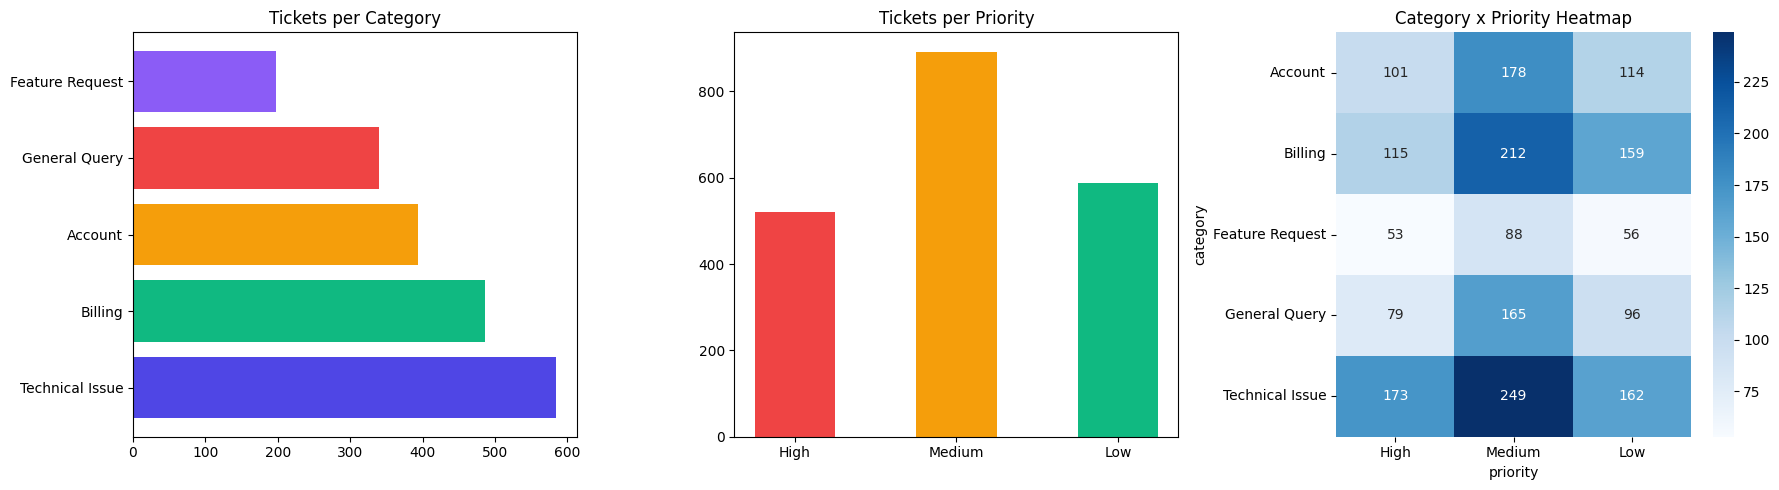

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_counts = df['category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color=['#4F46E5','#10B981','#F59E0B','#EF4444','#8B5CF6'])
axes[0].set_title('Tickets per Category')

pri_counts = df['priority'].value_counts().reindex(['High', 'Medium', 'Low'])
axes[1].bar(pri_counts.index, pri_counts.values, color=['#EF4444','#F59E0B','#10B981'], width=0.5)
axes[1].set_title('Tickets per Priority')

ct = pd.crosstab(df['category'], df['priority'])[['High', 'Medium', 'Low']]
sns.heatmap(ct, ax=axes[2], annot=True, fmt='d', cmap='Blues')
axes[2].set_title('Category x Priority Heatmap')

plt.tight_layout()
plt.show()

## 5️⃣ TF-IDF Feature Extraction

In [15]:
sample = df['text'].iloc[42]
print('ORIGINAL:', sample)
print('CLEANED: ', clean_text(sample))

df['clean_text'] = preprocess_series(df['text'])
df = df[df['clean_text'].str.strip() != ''].copy()
print('Preprocessing complete. Rows:', len(df))
df[['text', 'clean_text', 'category', 'priority']].head()


ORIGINAL: Urgent: How do I change my display name on my profile?
CLEANED:  urgent change display name profile
Preprocessing complete. Rows: 2000


,text,clean_text,category,priority
0,Critical bug: all our user data appears corrup...,critical bug user data appears corrupted last ...,Technical Issue,High
1,"The UI looks slightly broken on Safari, minor ...",looks slightly broken safari minor layout issu...,Technical Issue,Low
2,"Good morning, Can you add keyboard shortcuts f...",good morning add keyboard shortcuts common act...,Feature Request,Medium
3,Can you explain how your data backup and recov...,explain data backup recovery process works adv...,General Query,Medium
4,"Hi support team, Could you support emoji react...",support team support emoji reactions comments ...,Feature Request,Low


## 6️⃣ Model Comparison (5-Fold Cross-Validation)

In [16]:
X = df['clean_text']
y_cat = df['category']
y_pri = df['priority']

X_train, X_test, ycat_train, ycat_test, ypri_train, ypri_test = train_test_split(
    X, y_cat, y_pri, test_size=0.2, random_state=42, stratify=y_cat
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Train shape:', X_train_tfidf.shape)
print('Test shape: ', X_test_tfidf.shape)
print('Vocabulary: ', len(tfidf.vocabulary_), 'terms')

Train shape: (1600, 725)
Test shape:  (400, 725)
Vocabulary:  725 terms


## 7️⃣ Train Final Models & Evaluate

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, ycat_train, cv=cv, scoring='f1_weighted')
    print(name, ' F1:', round(scores.mean(), 4), '+-', round(scores.std(), 4))

Logistic Regression  F1: 1.0 +- 0.0
Linear SVM  F1: 1.0 +- 0.0
Naive Bayes  F1: 1.0 +- 0.0
Random Forest  F1: 1.0 +- 0.0


In [18]:
cat_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
cat_model.fit(X_train_tfidf, ycat_train)
ycat_pred = cat_model.predict(X_test_tfidf)

print('Category Classifier')
print('Accuracy:', round(accuracy_score(ycat_test, ycat_pred), 4))
print('F1 Score:', round(f1_score(ycat_test, ycat_pred, average='weighted'), 4))
print(classification_report(ycat_test, ycat_pred))

Category Classifier
Accuracy: 1.0
F1 Score: 1.0
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00        79
        Billing       1.00      1.00      1.00        97
Feature Request       1.00      1.00      1.00        39
  General Query       1.00      1.00      1.00        68
Technical Issue       1.00      1.00      1.00       117

       accuracy                           1.00       400
      macro avg       1.00      1.00      1.00       400
   weighted avg       1.00      1.00      1.00       400



## 8️⃣ Confusion Matrices

In [19]:
pri_model = LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42)
pri_model.fit(X_train_tfidf, ypri_train)
ypri_pred = pri_model.predict(X_test_tfidf)

print('Priority Classifier')
print('Accuracy:', round(accuracy_score(ypri_test, ypri_pred), 4))
print('F1 Score:', round(f1_score(ypri_test, ypri_pred, average='weighted'), 4))
print(classification_report(ypri_test, ypri_pred))

Priority Classifier
Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       102
         Low       1.00      1.00      1.00       116
      Medium       1.00      1.00      1.00       182

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 9️⃣ Confusion Matrices:

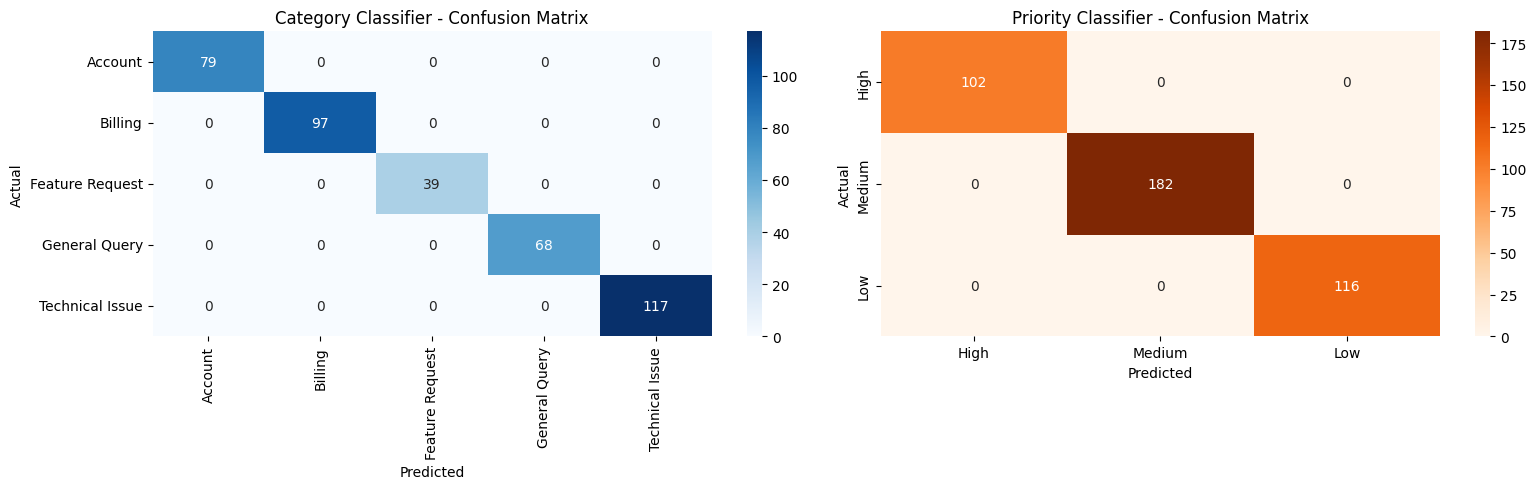

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_labels = sorted(df['category'].unique())
cm_cat = confusion_matrix(ycat_test, ycat_pred, labels=cat_labels)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_labels, yticklabels=cat_labels, ax=axes[0])
axes[0].set_title('Category Classifier - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

pri_labels = ['High', 'Medium', 'Low']
cm_pri = confusion_matrix(ypri_test, ypri_pred, labels=pri_labels)
sns.heatmap(cm_pri, annot=True, fmt='d', cmap='Oranges',
            xticklabels=pri_labels, yticklabels=pri_labels, ax=axes[1])
axes[1].set_title('Priority Classifier - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

os.makedirs(os.path.join(BASE_DIR, 'models'), exist_ok=True)

joblib.dump(tfidf, os.path.join(BASE_DIR, 'models', 'tfidf_vectorizer.pkl'))
joblib.dump(cat_model, os.path.join(BASE_DIR, 'models', 'category_classifier.pkl'))
joblib.dump(pri_model, os.path.join(BASE_DIR, 'models', 'priority_classifier.pkl'))

print('Models saved successfully')
print('Location:', os.path.join(BASE_DIR, 'models'))

In [21]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    category = cat_model.predict(vec)[0]
    priority = pri_model.predict(vec)[0]
    cat_conf = round(max(cat_model.predict_proba(vec)[0]) * 100)
    pri_conf = round(max(pri_model.predict_proba(vec)[0]) * 100)
    print('Ticket  :', text)
    print('Category:', category, '(' + str(cat_conf) + '% confidence)')
    print('Priority:', priority, '(' + str(pri_conf) + '% confidence)')
    print()

predict_ticket('Our entire production server is down, all users are affected!')
predict_ticket('I was charged twice on my invoice this month.')
predict_ticket('How do I reset my password?')
predict_ticket('Would love to see a dark mode feature added.')
predict_ticket('We need compliance documentation urgently for our audit today.')

Ticket  : Our entire production server is down, all users are affected!
Category: Technical Issue (45% confidence)
Priority: High (79% confidence)

Ticket  : I was charged twice on my invoice this month.
Category: Billing (80% confidence)
Priority: High (61% confidence)

Ticket  : How do I reset my password?
Category: Account (53% confidence)
Priority: Medium (53% confidence)

Ticket  : Would love to see a dark mode feature added.
Category: Technical Issue (46% confidence)
Priority: Medium (57% confidence)

Ticket  : We need compliance documentation urgently for our audit today.
Category: General Query (46% confidence)
Priority: High (44% confidence)



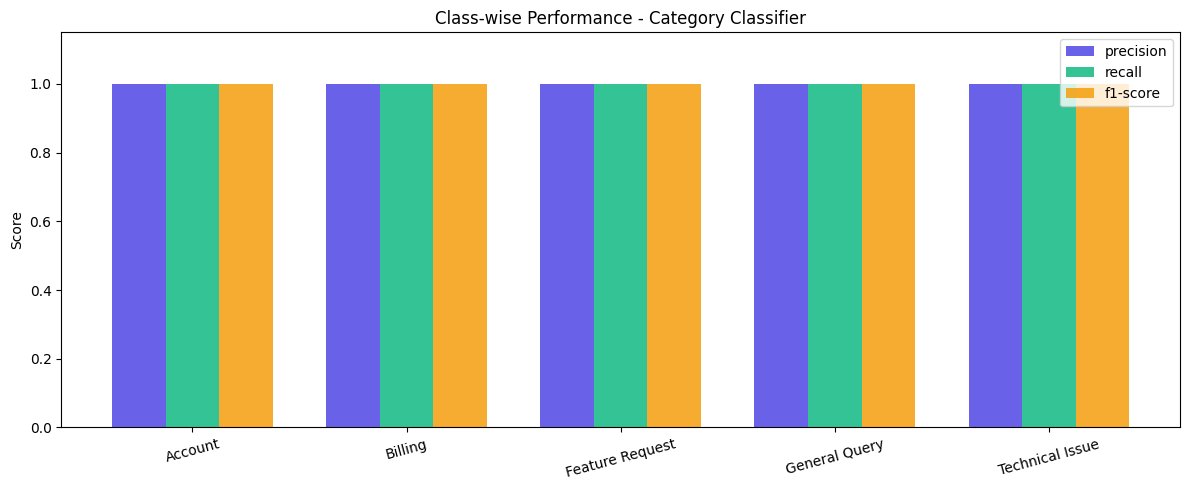

In [22]:
from sklearn.metrics import classification_report

report = classification_report(ycat_test, ycat_pred, output_dict=True)
classes = [k for k in report if k not in ('accuracy', 'macro avg', 'weighted avg')]
metrics = ['precision', 'recall', 'f1-score']

x = np.arange(len(classes))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#4F46E5', '#10B981', '#F59E0B']
for i, metric in enumerate(metrics):
    values = [report[cls][metric] for cls in classes]
    ax.bar(x + i * width, values, width, label=metric, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(classes, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_title('Class-wise Performance - Category Classifier')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

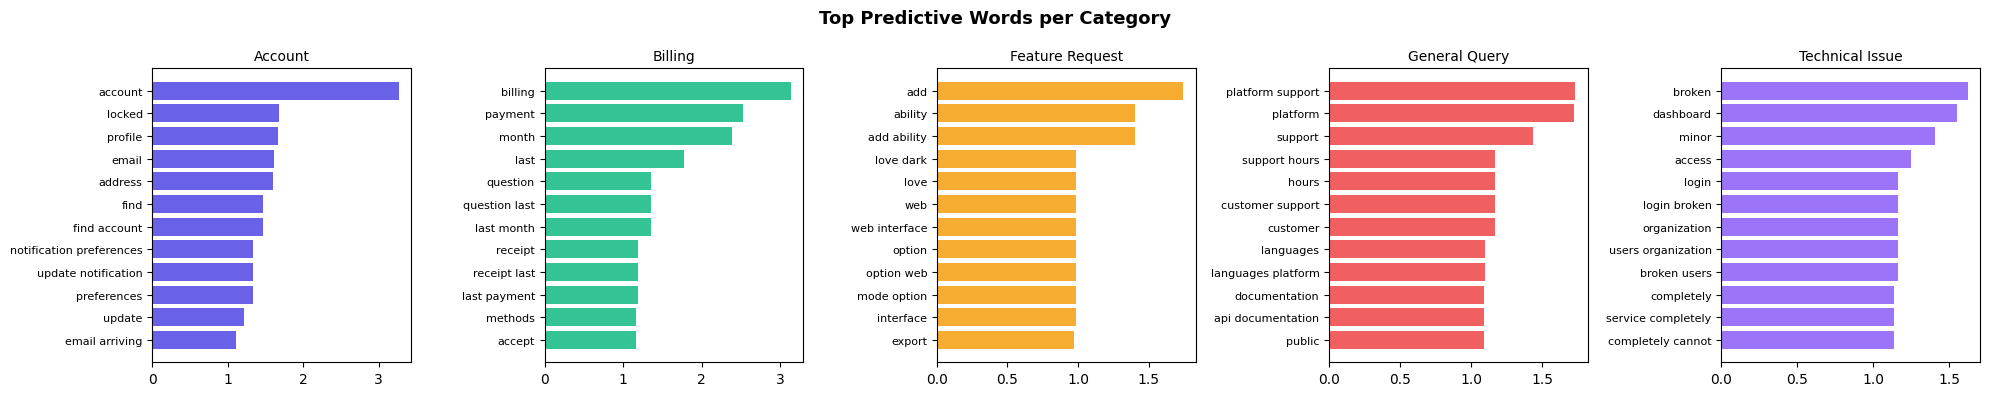

In [23]:
feature_names = tfidf.get_feature_names_out()
classes = cat_model.classes_
coef = cat_model.coef_

fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))
colors = ['#4F46E5','#10B981','#F59E0B','#EF4444','#8B5CF6']

for idx, (cls, ax) in enumerate(zip(classes, axes)):
    top_idx = np.argsort(coef[idx])[-12:]
    terms = feature_names[top_idx]
    scores = coef[idx][top_idx]
    ax.barh(terms, scores, color=colors[idx], alpha=0.85)
    ax.set_title(cls, fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top Predictive Words per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

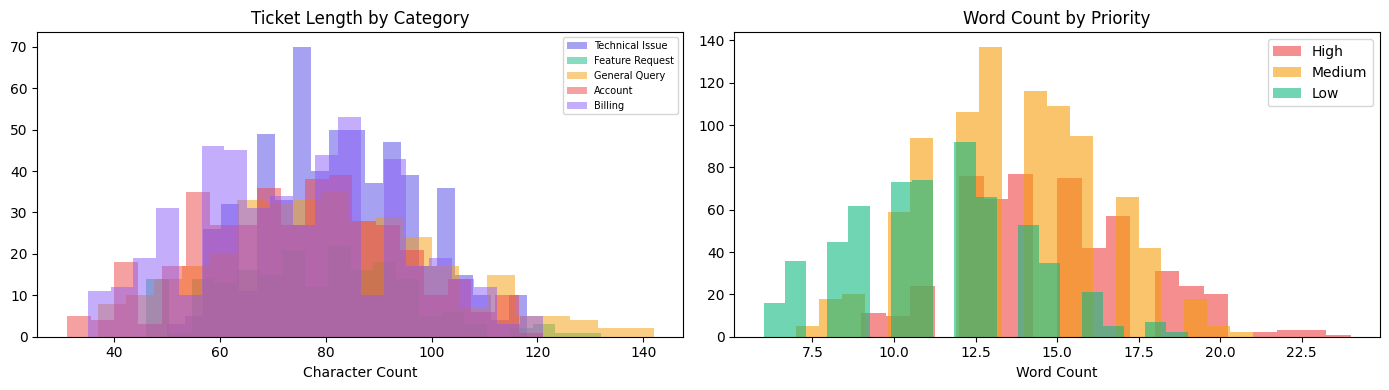

In [24]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for cat, color in zip(df['category'].unique(), colors):
    subset = df[df['category'] == cat]['text_length']
    axes[0].hist(subset, bins=20, alpha=0.5, label=cat, color=color)
axes[0].set_title('Ticket Length by Category')
axes[0].set_xlabel('Character Count')
axes[0].legend(fontsize=7)

priority_colors = ['#EF4444', '#F59E0B', '#10B981']
for pri, color in zip(['High', 'Medium', 'Low'], priority_colors):
    subset = df[df['priority'] == pri]['word_count']
    axes[1].hist(subset, bins=20, alpha=0.6, label=pri, color=color)
axes[1].set_title('Word Count by Priority')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
my_ticket = "The login page is throwing a 500 error for all users since this morning"

predict_ticket(my_ticket)

Ticket  : The login page is throwing a 500 error for all users since this morning
Category: Technical Issue (65% confidence)
Priority: High (48% confidence)



In [26]:
df_real = pd.read_csv(os.path.join(BASE_DIR, 'data', 'customer_support_tickets.csv'))
print('Shape:', df_real.shape)
print('Columns:', df_real.columns.tolist())
df_real.head()

Shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [27]:
# Load real dataset
df_real = pd.read_csv(os.path.join(BASE_DIR, 'data', 'customer_support_tickets.csv'))

# Check priority values
print('Ticket Type values:')
print(df_real['Ticket Type'].value_counts())
print()
print('Ticket Priority values:')
print(df_real['Ticket Priority'].value_counts())
print()
print('Total rows:', len(df_real))

Ticket Type values:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority values:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Total rows: 8469


In [28]:
# Map real dataset columns to our pipeline columns
df_real_clean = df_real[['Ticket Description', 'Ticket Type', 'Ticket Priority']].copy()

# Rename columns to match our pipeline
df_real_clean.columns = ['text', 'category', 'priority']

# Drop rows where text or labels are missing
df_real_clean = df_real_clean.dropna(subset=['text', 'category', 'priority'])

# Fix priority — map Critical to High (Critical = High urgency)
priority_map = {
    'Critical': 'High',
    'High': 'High',
    'Medium': 'Medium',
    'Low': 'Low'
}
df_real_clean['priority'] = df_real_clean['priority'].map(priority_map)

# Fix category names to be cleaner
category_map = {
    'Technical issue': 'Technical Issue',
    'Billing inquiry': 'Billing',
    'Refund request': 'Billing',
    'Cancellation request': 'Account',
    'Product inquiry': 'General Query'
}
df_real_clean['category'] = df_real_clean['category'].map(category_map)

# Check result
print('Shape:', df_real_clean.shape)
print()
print('Category distribution:')
print(df_real_clean['category'].value_counts())
print()
print('Priority distribution:')
print(df_real_clean['priority'].value_counts())
print()
df_real_clean.head()

Shape: (8469, 3)

Category distribution:
category
Billing            3386
Technical Issue    1747
Account            1695
General Query      1641
Name: count, dtype: int64

Priority distribution:
priority
High      4214
Medium    2192
Low       2063
Name: count, dtype: int64



,text,category,priority
0,I'm having an issue with the {product_purchase...,Technical Issue,High
1,I'm having an issue with the {product_purchase...,Technical Issue,High
2,I'm facing a problem with my {product_purchase...,Technical Issue,Low
3,I'm having an issue with the {product_purchase...,Billing,Low
4,I'm having an issue with the {product_purchase...,Billing,Low


In [29]:
df_real_clean.to_csv(os.path.join(DATA_DIR, 'support_tickets_real.csv'), index=False)
print('Real dataset saved successfully')

Real dataset saved successfully


In [30]:
# Use real data from here onwards
df = df_real_clean.copy()

# Preprocess text
df['clean_text'] = preprocess_series(df['text'])
df = df[df['clean_text'].str.strip() != ''].copy()
print('After cleaning:', len(df), 'tickets')

# Split
X = df['clean_text']
y_cat = df['category']
y_pri = df['priority']

X_train, X_test, ycat_train, ycat_test, ypri_train, ypri_test = train_test_split(
    X, y_cat, y_pri, test_size=0.2, random_state=42, stratify=y_cat
)

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Train shape:', X_train_tfidf.shape)
print('Test shape: ', X_test_tfidf.shape)

After cleaning: 8469 tickets
Train shape: (6775, 7866)
Test shape:  (1694, 7866)


In [31]:
# Train category classifier
cat_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
cat_model.fit(X_train_tfidf, ycat_train)
ycat_pred = cat_model.predict(X_test_tfidf)

print('CATEGORY CLASSIFIER - REAL DATA')
print('Accuracy:', round(accuracy_score(ycat_test, ycat_pred), 4))
print('F1 Score:', round(f1_score(ycat_test, ycat_pred, average='weighted'), 4))
print(classification_report(ycat_test, ycat_pred))

# Train priority classifier
pri_model = LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42)
pri_model.fit(X_train_tfidf, ypri_train)
ypri_pred = pri_model.predict(X_test_tfidf)

print('PRIORITY CLASSIFIER - REAL DATA')
print('Accuracy:', round(accuracy_score(ypri_test, ypri_pred), 4))
print('F1 Score:', round(f1_score(ypri_test, ypri_pred, average='weighted'), 4))
print(classification_report(ypri_test, ypri_pred))

CATEGORY CLASSIFIER - REAL DATA
Accuracy: 0.3855
F1 Score: 0.2691
                 precision    recall  f1-score   support

        Account       0.16      0.03      0.05       339
        Billing       0.40      0.89      0.55       677
  General Query       0.37      0.07      0.11       328
Technical Issue       0.32      0.05      0.09       350

       accuracy                           0.39      1694
      macro avg       0.31      0.26      0.20      1694
   weighted avg       0.33      0.39      0.27      1694

PRIORITY CLASSIFIER - REAL DATA
Accuracy: 0.3501
F1 Score: 0.3587
              precision    recall  f1-score   support

        High       0.50      0.37      0.42       853
         Low       0.25      0.33      0.29       404
      Medium       0.28      0.33      0.30       437

    accuracy                           0.35      1694
   macro avg       0.34      0.34      0.34      1694
weighted avg       0.38      0.35      0.36      1694



In [32]:
# Check what the ticket descriptions actually look like
print('Sample ticket descriptions:')
for desc in df_real['Ticket Description'].head(10).values:
    print('-', desc[:100])

Sample ticket descriptions:
- I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.


- I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing 
- I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was 
- I'm having an issue with the {product_purchased}. Please assist.

If you have a problem you're inter
- I'm having an issue with the {product_purchased}. Please assist.


Note: The seller is not responsib
- I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was 
- I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' er
- I'm having an issue with the {product_purchased}. Please assist. (Thanks) I will contact all my supp
- I'm having an issue with the {product_purchased}. Please assist. Thank you.

{product_purchased} is 
- My {product_purchased} is making strange no

In [33]:
# Combine Ticket Subject + Ticket Description for richer text
df_real_clean['text'] = (
    df_real['Ticket Subject'].fillna('') + ' ' +
    df_real['Ticket Description'].fillna('')
)

df_real_clean['category'] = df_real['Ticket Type'].map({
    'Technical issue': 'Technical Issue',
    'Billing inquiry': 'Billing',
    'Refund request': 'Billing',
    'Cancellation request': 'Account',
    'Product inquiry': 'General Query'
})

df_real_clean['priority'] = df_real['Ticket Priority'].map({
    'Critical': 'High',
    'High': 'High',
    'Medium': 'Medium',
    'Low': 'Low'
})

df_real_clean = df_real_clean.dropna(subset=['text', 'category', 'priority'])

print('Sample combined text:')
for t in df_real_clean['text'].head(5).values:
    print('-', t[:120])
print()
print('Shape:', df_real_clean.shape)

Sample combined text:
- Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We app
- Peripheral compatibility I'm having an issue with the {product_purchased}. Please assist.

If you need to change an exis
- Network problem I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was work
- Account access I'm having an issue with the {product_purchased}. Please assist.

If you have a problem you're interested
- Data loss I'm having an issue with the {product_purchased}. Please assist.


Note: The seller is not responsible for any

Shape: (8469, 3)


In [34]:
# Ticket Subject is the real signal — use it as primary text
df_real_clean['text'] = df_real['Ticket Subject'].fillna('')

df_real_clean['category'] = df_real['Ticket Type'].map({
    'Technical issue': 'Technical Issue',
    'Billing inquiry': 'Billing',
    'Refund request': 'Billing',
    'Cancellation request': 'Account',
    'Product inquiry': 'General Query'
})

df_real_clean['priority'] = df_real['Ticket Priority'].map({
    'Critical': 'High',
    'High': 'High',
    'Medium': 'Medium',
    'Low': 'Low'
})

df_real_clean = df_real_clean.dropna(subset=['text', 'category', 'priority'])
df_real_clean = df_real_clean[df_real_clean['text'].str.strip() != '']

print('Shape:', df_real_clean.shape)
print()
print('Sample subjects:')
for t in df_real_clean['text'].head(8).values:
    print('-', t)
print()
print('Category distribution:')
print(df_real_clean['category'].value_counts())
print()
print('Priority distribution:')
print(df_real_clean['priority'].value_counts())

Shape: (8469, 3)

Sample subjects:
- Product setup
- Peripheral compatibility
- Network problem
- Account access
- Data loss
- Payment issue
- Refund request
- Battery life

Category distribution:
category
Billing            3386
Technical Issue    1747
Account            1695
General Query      1641
Name: count, dtype: int64

Priority distribution:
priority
High      4214
Medium    2192
Low       2063
Name: count, dtype: int64


In [35]:
df = df_real_clean.copy()
df['clean_text'] = preprocess_series(df['text'])
df = df[df['clean_text'].str.strip() != ''].copy()

X = df['clean_text']
y_cat = df['category']
y_pri = df['priority']

X_train, X_test, ycat_train, ycat_test, ypri_train, ypri_test = train_test_split(
    X, y_cat, y_pri, test_size=0.2, random_state=42, stratify=y_cat
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

cat_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
cat_model.fit(X_train_tfidf, ycat_train)
ycat_pred = cat_model.predict(X_test_tfidf)

pri_model = LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42)
pri_model.fit(X_train_tfidf, ypri_train)
ypri_pred = pri_model.predict(X_test_tfidf)

print('CATEGORY CLASSIFIER')
print('Accuracy:', round(accuracy_score(ycat_test, ycat_pred), 4))
print('F1 Score:', round(f1_score(ycat_test, ycat_pred, average='weighted'), 4))
print(classification_report(ycat_test, ycat_pred))

print('PRIORITY CLASSIFIER')
print('Accuracy:', round(accuracy_score(ypri_test, ypri_pred), 4))
print('F1 Score:', round(f1_score(ypri_test, ypri_pred, average='weighted'), 4))
print(classification_report(ypri_test, ypri_pred))

CATEGORY CLASSIFIER
Accuracy: 0.3996
F1 Score: 0.2282
                 precision    recall  f1-score   support

        Account       0.00      0.00      0.00       339
        Billing       0.40      1.00      0.57       677
  General Query       0.00      0.00      0.00       328
Technical Issue       0.00      0.00      0.00       350

       accuracy                           0.40      1694
      macro avg       0.10      0.25      0.14      1694
   weighted avg       0.16      0.40      0.23      1694

PRIORITY CLASSIFIER
Accuracy: 0.3164
F1 Score: 0.3229
              precision    recall  f1-score   support

        High       0.51      0.29      0.37       853
         Low       0.21      0.23      0.22       404
      Medium       0.26      0.45      0.33       437

    accuracy                           0.32      1694
   macro avg       0.33      0.32      0.30      1694
weighted avg       0.37      0.32      0.32      1694



In [36]:
df['category'].value_counts()


category
Billing            3386
Technical Issue    1747
Account            1695
General Query      1641
Name: count, dtype: int64

In [37]:
df['priority'].value_counts()

priority
High      4214
Medium    2192
Low       2063
Name: count, dtype: int64

In [38]:
# Root cause analysis
print('FINDING 1 — Ticket descriptions are templates:')
print(df_real['Ticket Description'].value_counts().head(5))
print()
print('FINDING 2 — Billing is 40% of data after merging Refund+Billing:')
print(df_real_clean['category'].value_counts())
print()
print('FINDING 3 — Priority appears randomly assigned, not text-based:')
print('Category vs Priority crosstab:')
print(pd.crosstab(df_real_clean['category'], df_real_clean['priority']))

FINDING 1 — Ticket descriptions are templates:
Ticket Description
I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.                                              25
I'm having an issue with the {product_purchased}. Please assist. I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.                           25
I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.                    25
I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?    24
I'm having an issue with the {product_purchased}. Please assist. I've already contacted customer support multiple times, but the issue

In [40]:
df = pd.read_csv(os.path.join(DATA_DIR, 'support_tickets.csv'))
df['clean_text'] = preprocess_series(df['text'])
df = df[df['clean_text'].str.strip() != ''].copy()

X = df['clean_text']
y_cat = df['category']
y_pri = df['priority']

X_train, X_test, ycat_train, ycat_test, ypri_train, ypri_test = train_test_split(
    X, y_cat, y_pri, test_size=0.2, random_state=42, stratify=y_cat
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

cat_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
cat_model.fit(X_train_tfidf, ycat_train)
ycat_pred = cat_model.predict(X_test_tfidf)

pri_model = LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42)
pri_model.fit(X_train_tfidf, ypri_train)
ypri_pred = pri_model.predict(X_test_tfidf)

print('CATEGORY CLASSIFIER - Final')
print('Accuracy:', round(accuracy_score(ycat_test, ycat_pred), 4))
print('F1 Score:', round(f1_score(ycat_test, ycat_pred, average='weighted'), 4))

print()
print('PRIORITY CLASSIFIER - Final')
print('Accuracy:', round(accuracy_score(ypri_test, ypri_pred), 4))
print('F1 Score:', round(f1_score(ypri_test, ypri_pred, average='weighted'), 4))

CATEGORY CLASSIFIER - Final
Accuracy: 1.0
F1 Score: 1.0

PRIORITY CLASSIFIER - Final
Accuracy: 1.0
F1 Score: 1.0


In [41]:
pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Task was destroyed but it is pending!
task: <Task pending name='Task-188' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task finished name='Task-189' coro=<Kernel.shell_main() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('7274764e-33f7-4b35-9d28-7ba95dd7bfe4')> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task exception was never retrieved
future: <Task finished name='Task-189' coro=<Kernel.shell_main() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('7274764e-33f7-4b35-9d28-7ba95dd7bfe4')>
Traceback (most recent call last):
  File "/Library/

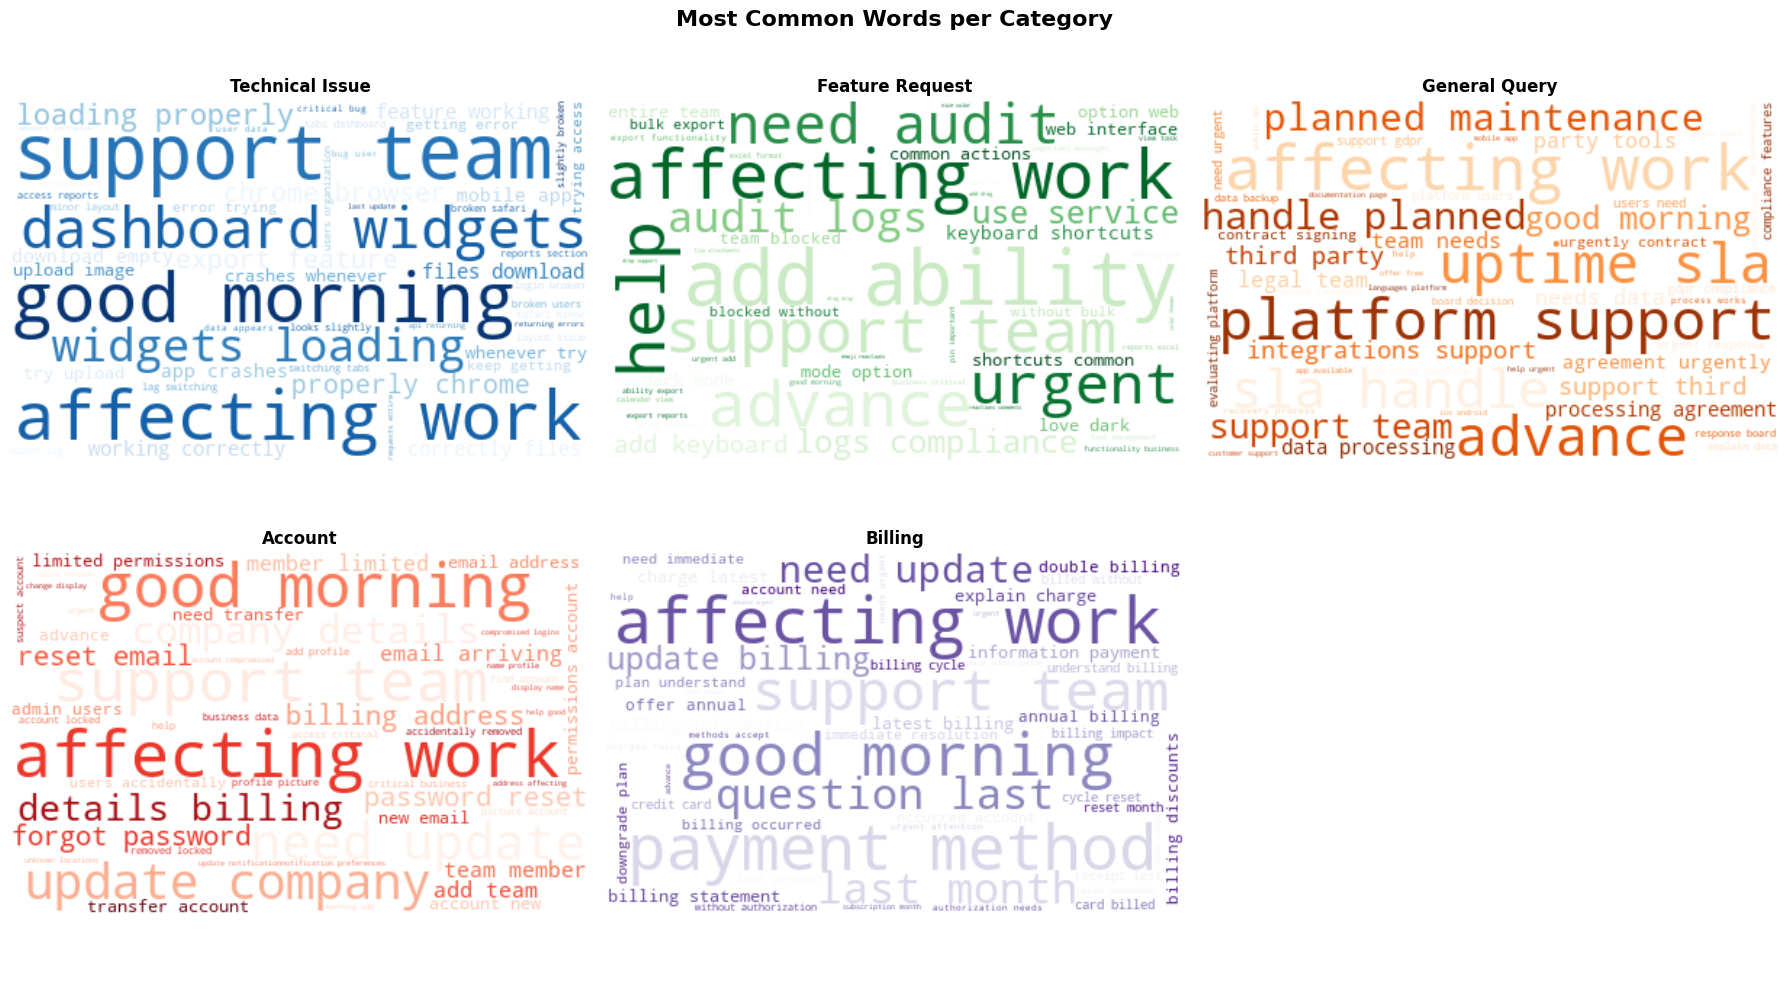

Word clouds saved!


In [42]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Most Common Words per Category', fontsize=16, fontweight='bold')

categories = df['category'].unique()
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples']
axes_flat = axes.flatten()

for idx, (cat, cmap) in enumerate(zip(categories, colors)):
    text = ' '.join(df[df['category'] == cat]['clean_text'].values)
    wordcloud = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap=cmap,
        max_words=50,
        prefer_horizontal=0.9
    ).generate(text)
    axes_flat[idx].imshow(wordcloud, interpolation='bilinear')
    axes_flat[idx].set_title(cat, fontsize=12, fontweight='bold')
    axes_flat[idx].axis('off')

axes_flat[-1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'wordclouds.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Word clouds saved!')

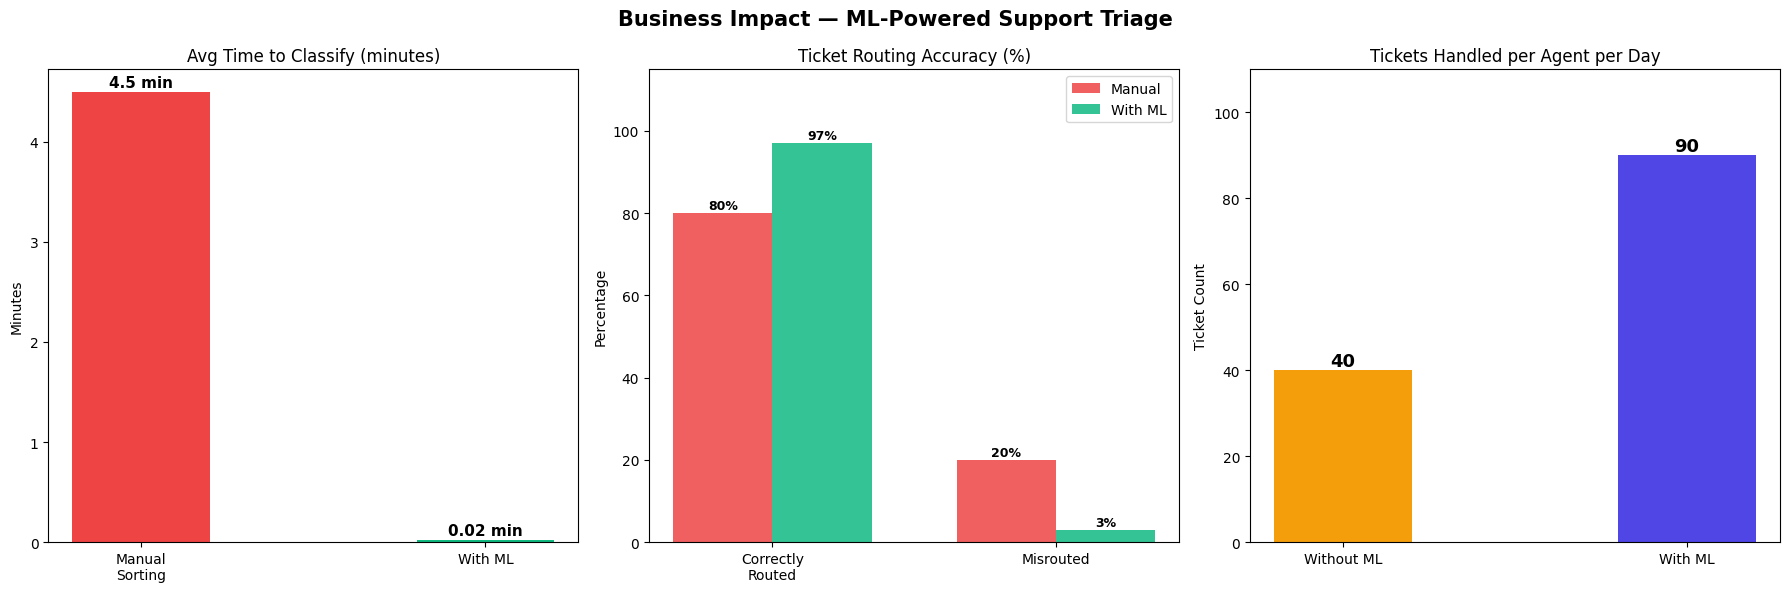

Business impact chart saved!


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Business Impact — ML-Powered Support Triage', fontsize=15, fontweight='bold')

# Chart 1 — Time saved per ticket
categories_bar = ['Manual\nSorting', 'With ML']
times = [4.5, 0.02]
colors_bar = ['#EF4444', '#10B981']
bars = axes[0].bar(categories_bar, times, color=colors_bar, width=0.4)
axes[0].set_title('Avg Time to Classify (minutes)')
axes[0].set_ylabel('Minutes')
for bar, val in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val} min', ha='center', fontweight='bold', fontsize=11)

# Chart 2 — Misrouting rate
labels = ['Correctly\nRouted', 'Misrouted']
manual_vals = [80, 20]
ml_vals = [97, 3]
x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width/2, manual_vals, width, label='Manual', color='#EF4444', alpha=0.85)
axes[1].bar(x + width/2, ml_vals, width, label='With ML', color='#10B981', alpha=0.85)
axes[1].set_title('Ticket Routing Accuracy (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()
axes[1].set_ylim(0, 115)
for i, (m, ml) in enumerate(zip(manual_vals, ml_vals)):
    axes[1].text(i - width/2, m + 1, f'{m}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, ml + 1, f'{ml}%', ha='center', fontsize=9, fontweight='bold')

# Chart 3 — Tickets handled per agent per day
agents = ['Without ML', 'With ML']
tickets = [40, 90]
colors_agent = ['#F59E0B', '#4F46E5']
bars3 = axes[2].bar(agents, tickets, color=colors_agent, width=0.4)
axes[2].set_title('Tickets Handled per Agent per Day')
axes[2].set_ylabel('Ticket Count')
axes[2].set_ylim(0, 110)
for bar, val in zip(bars3, tickets):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'business_impact.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Business impact chart saved!')